In [31]:
import switchy.CloneStats as cs
import switchy.util as ut
import pandas as pd
import numpy as np
import sys
import os
import time
import random
import copy
import math
import scanpy as sc
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import autoreload
import scipy
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 8,
    'ytick.labelsize': 10,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 100
   }
from nheatmap import nhm
mpl.rcParams.update(params)

sns.set_style("ticks")
sns.set_context(context='paper')
savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": False}
mpl.rc('savefig', dpi=300)
output_dir='figures/9.17.20_PaperDraft/'
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20) 
pd.set_option('display.width', 100)
%load_ext autoreload
%autoreload 2
cfgFile = '../switchy/Prototyping.ini'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
# Load SJout Data
ab_tx, switch_tx = ut.loadSJoutIGH('../../../SharedData/SJ/CombinedSJouts_chr14_IGH.fthr')

filtering SJout to just IGH locus
making SJTable human readable


In [33]:
parameters, io, config = cs.readConfig(cfgFile)
    
adata, df = cs.prepareData(io['CountsFile'],
                                parameters['datatype'], 
                                parameters.getboolean('highly_variable'),
                                int(parameters['n_highly_variable']),
                                parameters.getboolean('onlyClones'), 
                                parameters.getboolean('remove_immune_receptors'), 
                                parameters.getboolean('normalize'),
                                parameters.getboolean('filterCells'))

(1350, 10) (14714, 2) shape of adata after filtering 


In [34]:
# Filter Sjout to be only cells which pass QC
ab_tx = ab_tx[ab_tx.cell.isin(adata.obs.index)]

switch_tx = switch_tx[switch_tx.cell.isin(adata.obs.index)]

switch_tx['exon_start'] = switch_tx['exon_start'].str.split('_', expand = True)[0]
ab_tx['exon_start'] = ab_tx['exon_start'].str.split('_', expand = True)[0]

In [35]:
IgH_genes = ['IGHM', 'IGHD', 'IGHG3', 'IGHG1', 'IGHA1', "IGHG2", 'IGHG4','IGHE', 'IGHA2']


In [36]:
def clustermap(df):
    sum_df = df.groupby(['cell', 'exon_start']).sum()
    sum_df['uniquelog2'] = np.log10(sum_df['unique_mapping'])
    ret_df = sum_df.uniquelog2.unstack().fillna(np.log10(1))
    ret_df = ret_df[IgH_genes]
    sns.clustermap(ret_df)
    return ret_df

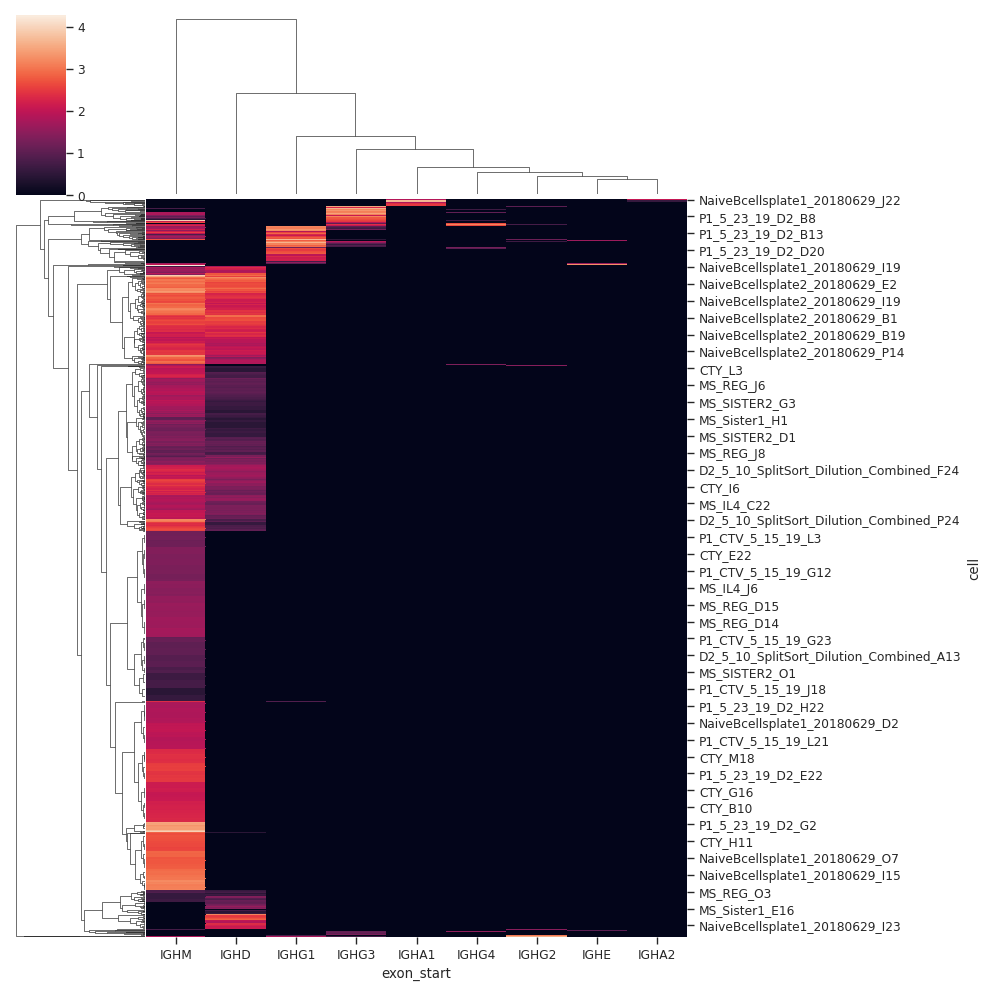

In [37]:
cellbygeneAb = clustermap(ab_tx)

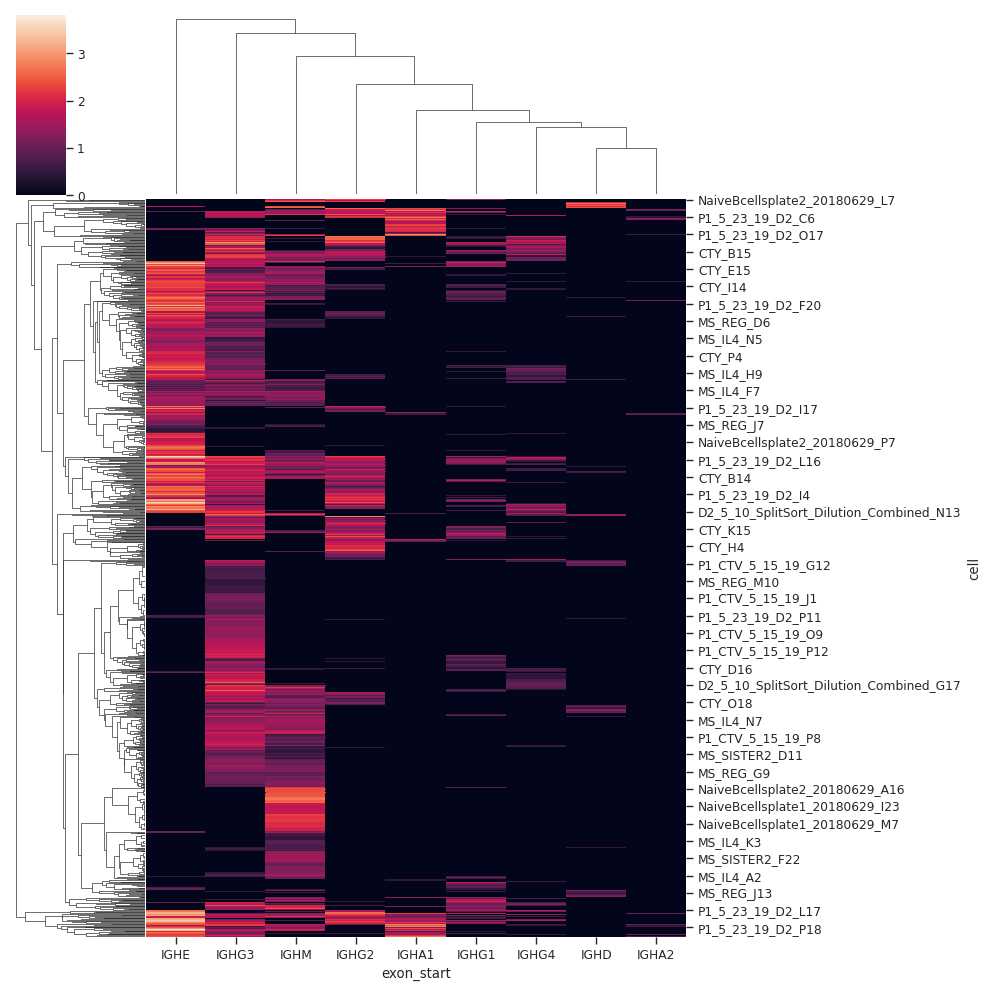

In [38]:
cellbygeneSwitch = clustermap(switch_tx)

In [39]:
def clean_df(dataframe):
    columns = dataframe.columns.to_list()
    rows = dataframe.index.to_list()
    return pd.DataFrame(data = dataframe.values, index=rows, columns=columns)

In [40]:
ab = clean_df(cellbygeneAb)

In [41]:
dfr = adata.obs[['Treatment', 'Division_Number', 'ISOTYPE']]
dfr.columns = ['Treatment', 'Division Number', 'Isotype']
_dfr = clean_df(dfr)
_dfr['Division Number'] = _dfr['Division Number'].replace('None', '0')
_dfr = _dfr[_dfr.Isotype.isin(IgH_genes)]
_df = df[df.index.isin(_dfr.index)]

In [42]:
cmaps={'Treatment':'Set1', 'PC1':'RdYlGn', 'gene cluster':'inferno',
        'Division Number':'Reds', 'Isotype':'Paired'}

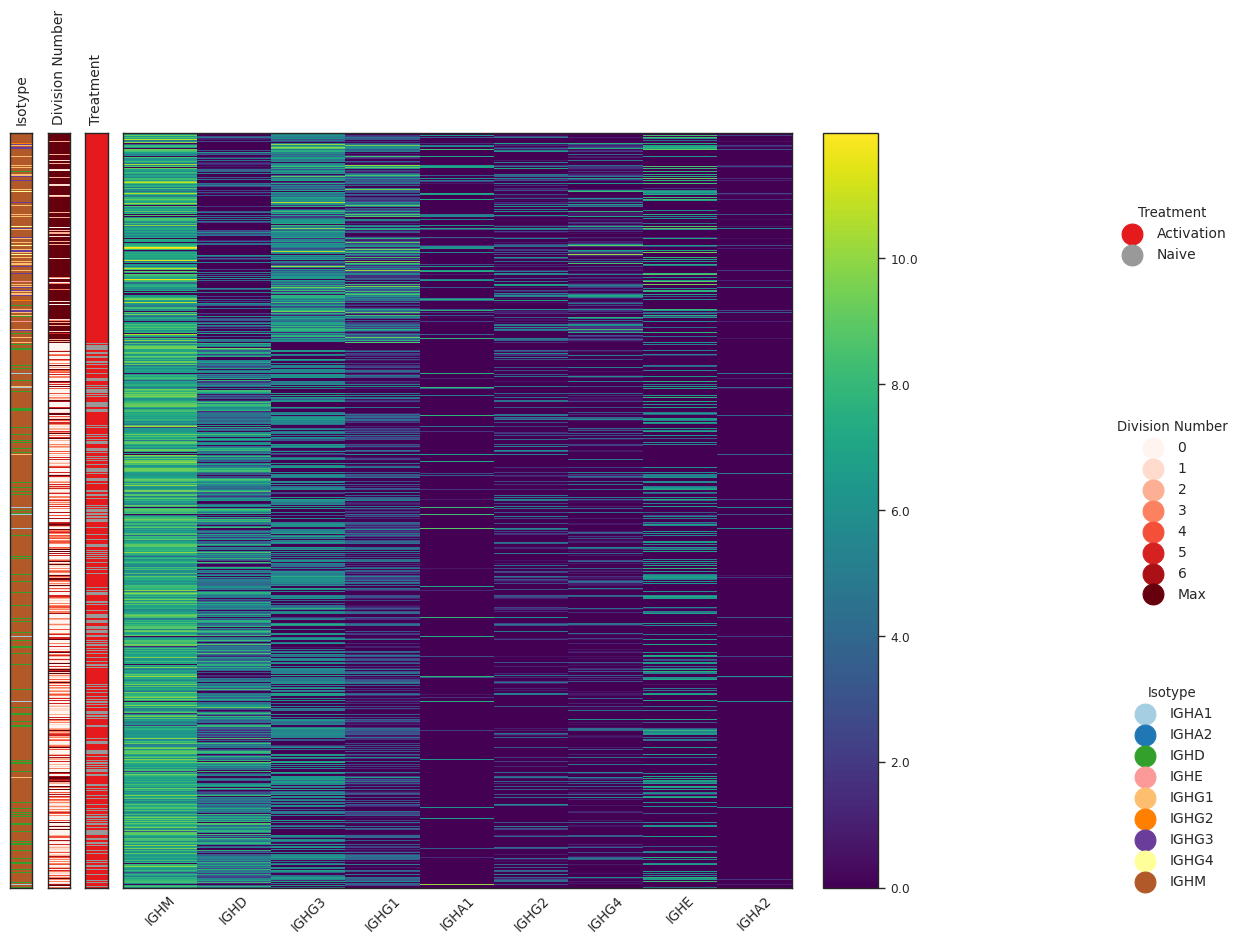

In [43]:
g = nhm(data=_df[IgH_genes], dfr=_dfr,figsize=(15, 10), linewidths=0, showxticks=True, cmaps=cmaps, srot = 90)
fig, plots = g.run()

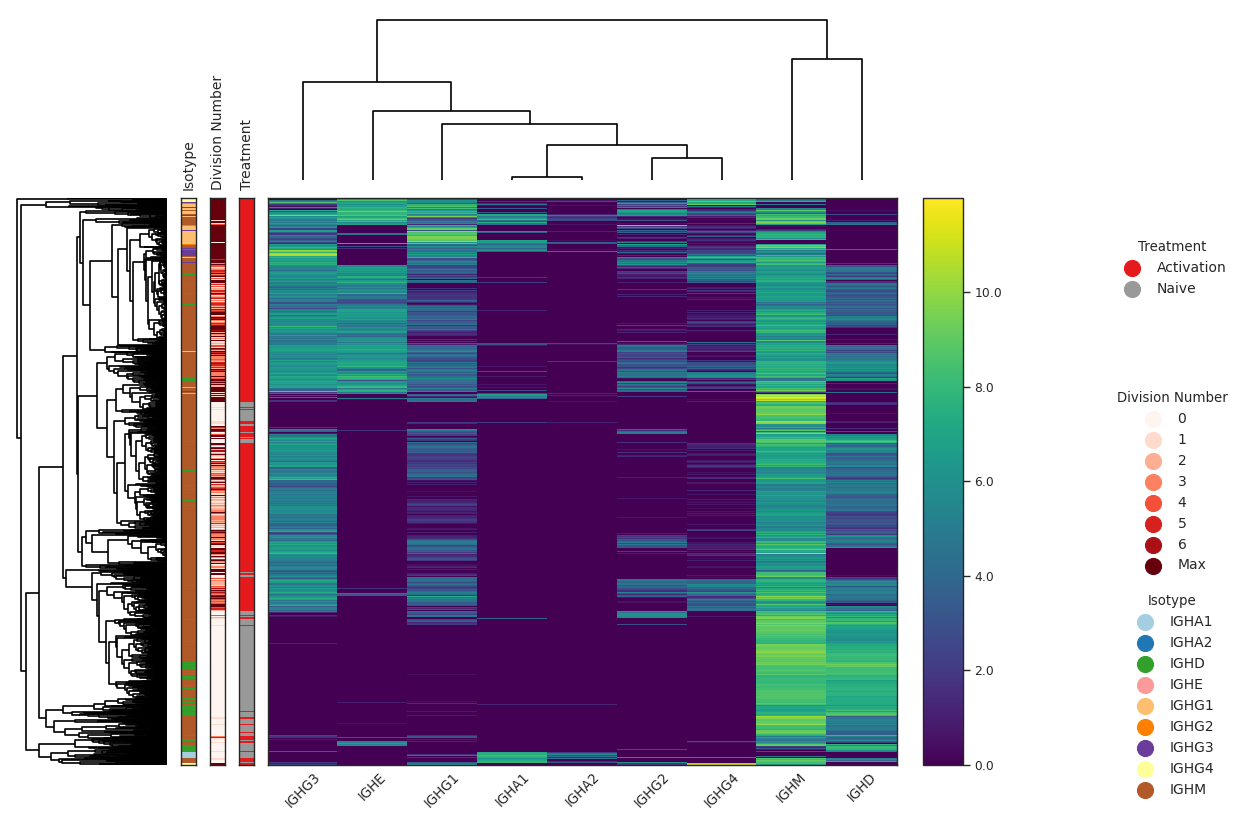

In [44]:
g.hcluster()
fig, plots = g.run()

In [45]:
save_figure(fig, 'nheatmap_IgH')

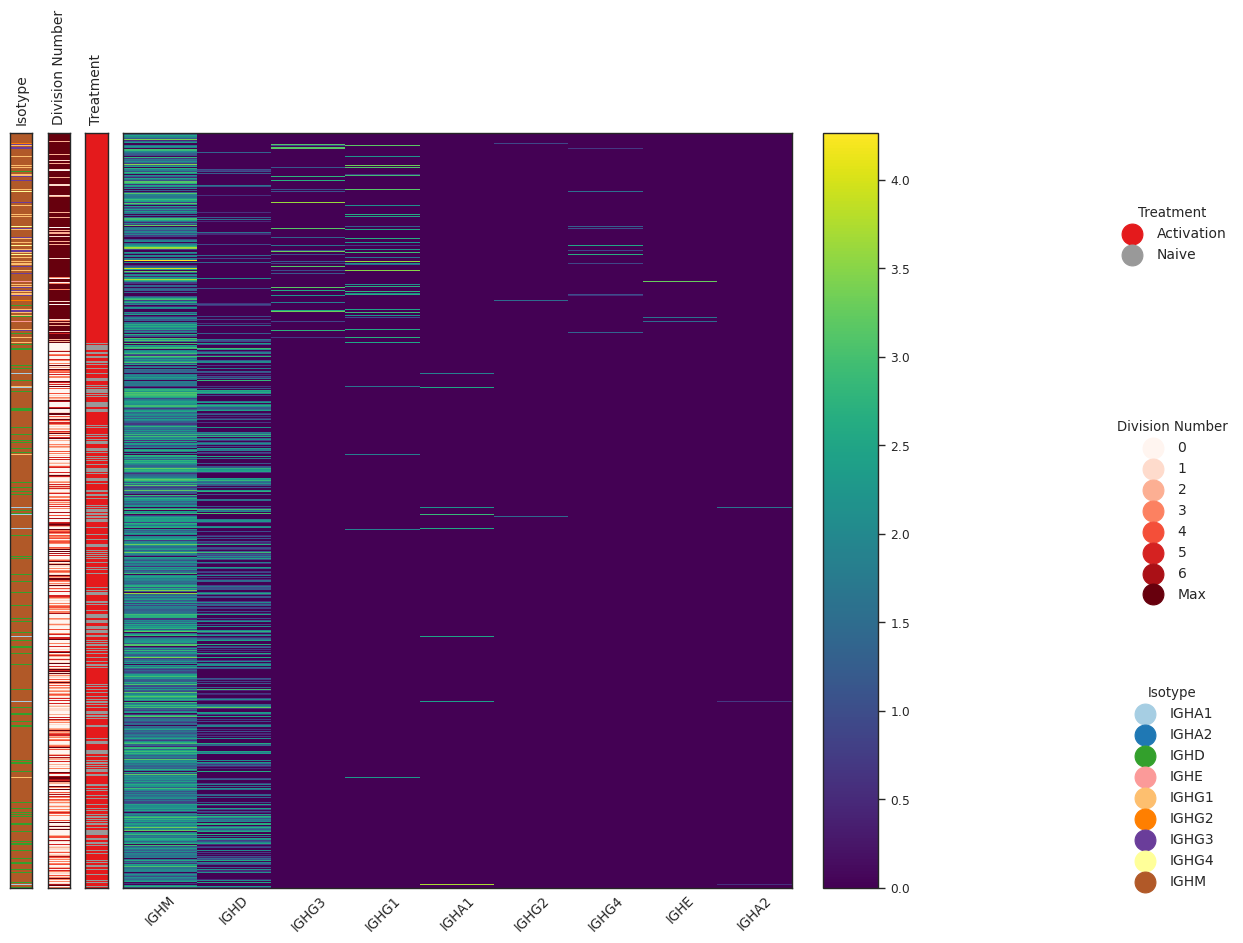

In [46]:
_df = cellbygeneAb

_df = pd.merge(_dfr, _df, left_index=True, right_index=True)

_dfr = _df.iloc[:,:3]
data = _df.iloc[:,3:]

g = nhm(data=data, dfr=_dfr,figsize=(15, 10), linewidths=0, showxticks=True, cmaps=cmaps, srot = 90, )
fig, plots = g.run()

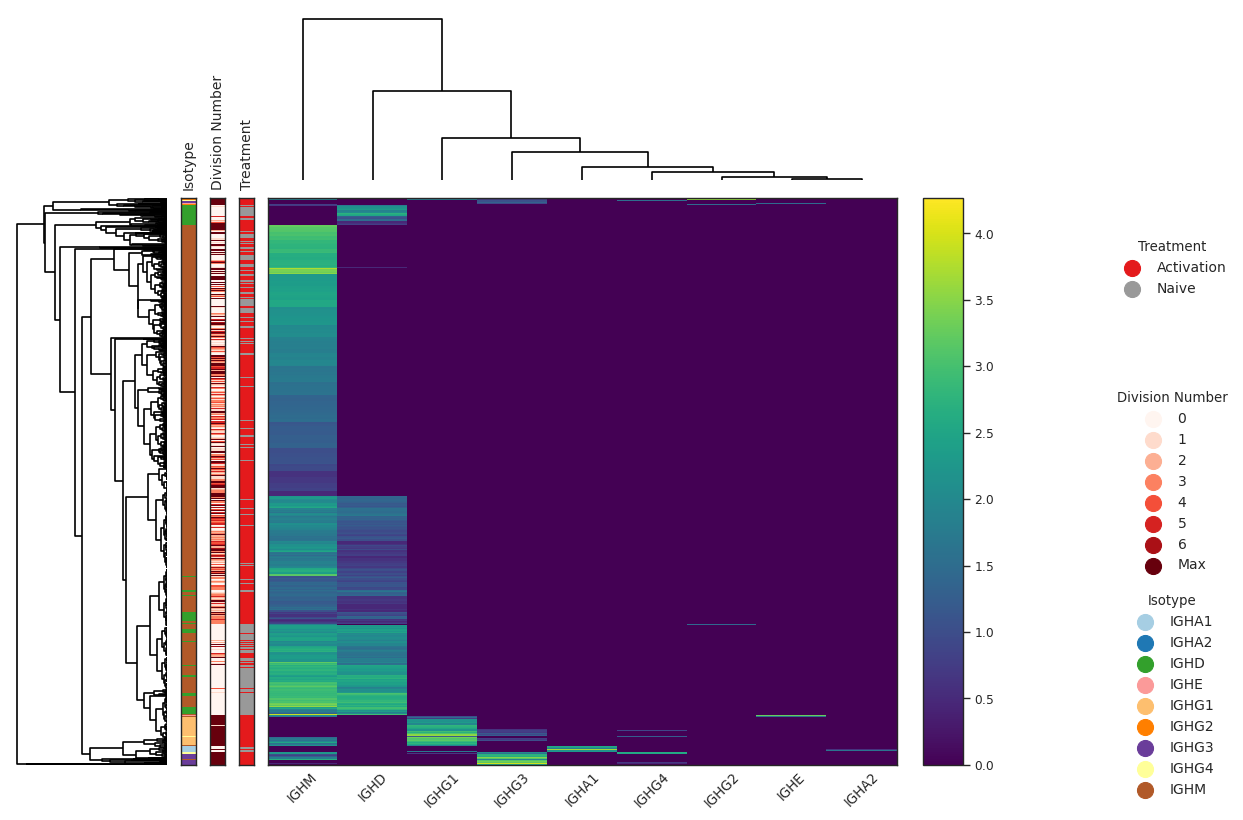

In [47]:
g.hcluster()
fig, plots = g.run()

In [48]:
save_figure(fig, "nheatmap_AbTx")

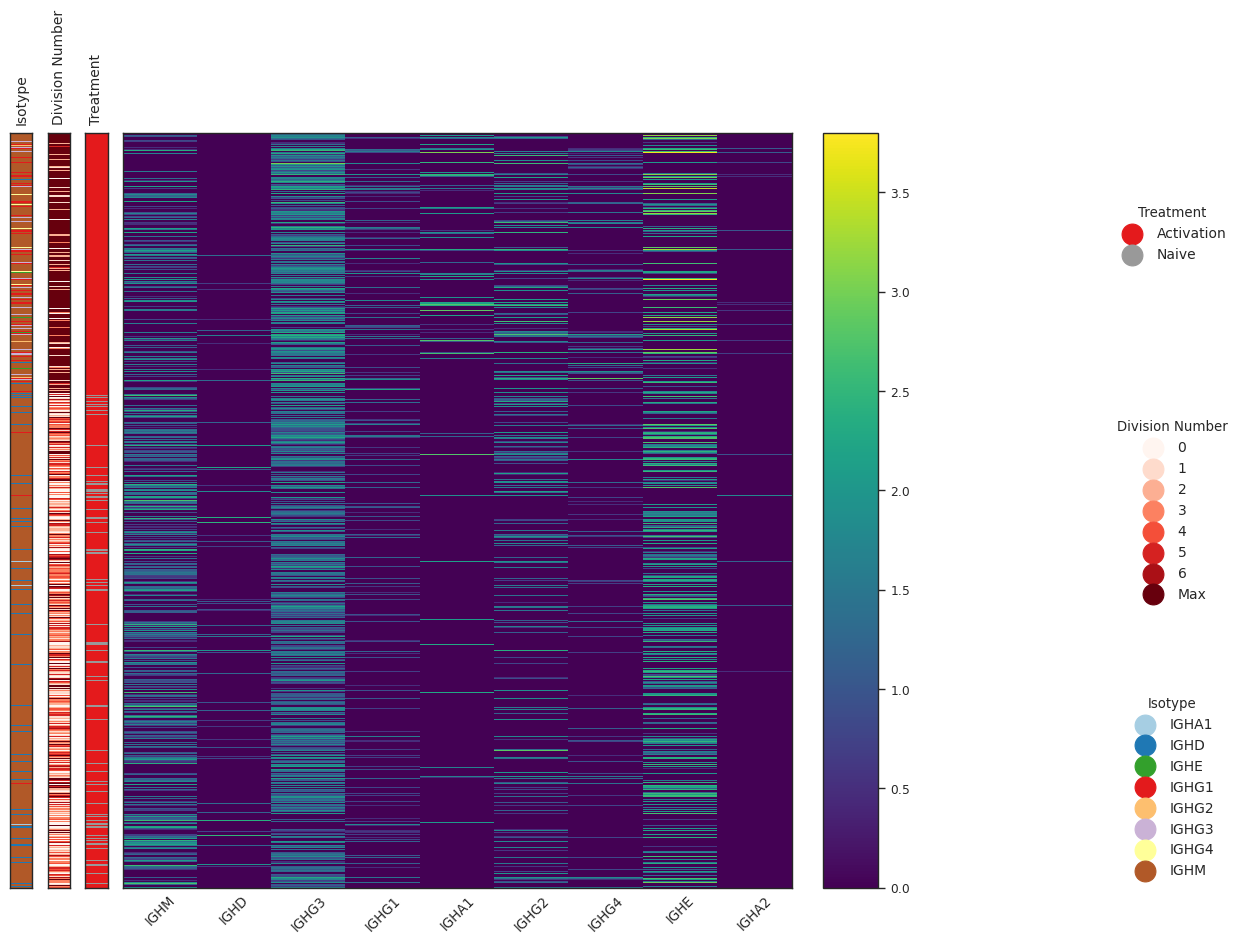

In [50]:
_df = cellbygeneSwitch

_df = pd.merge(_dfr, _df, left_index=True, right_index=True)

_dfr = _df.iloc[:,:3]
data = _df.iloc[:,3:]

g = nhm(data=data, dfr=_dfr,figsize=(15, 10), linewidths=0, showxticks=True, cmaps=cmaps, srot = 90, )
fig, plots = g.run()

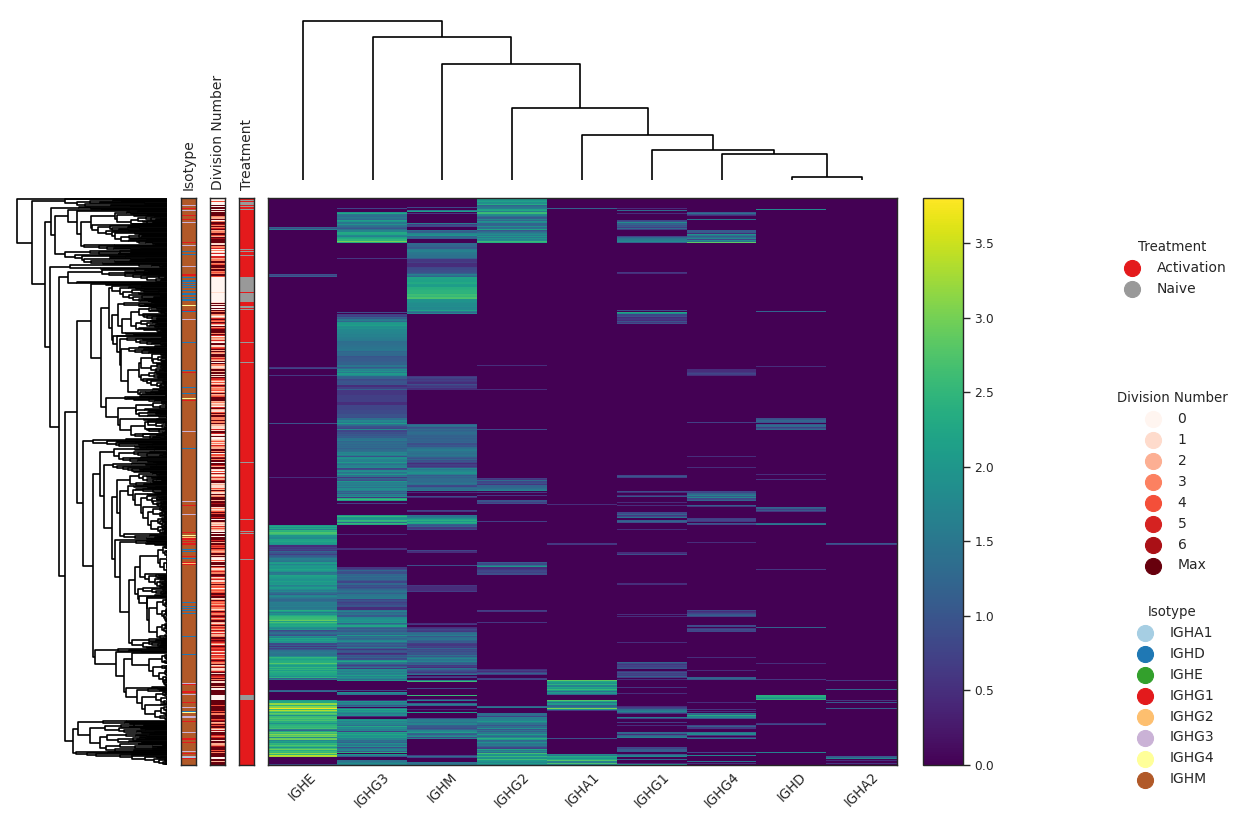

In [51]:
g.hcluster()
fig, plots = g.run()

In [52]:
save_figure(fig, "nheatmap_SwitchTX")